## Sea Slugs time series data
This notebook demonstrates how to fit hierarchical Hakwes functions (HHF) with scaled exponential excitation and inhibition functions to the Sea Slugs time series data. First, we import the data:

In [6]:
import numpy as np
## Import csv
X = np.loadtxt('../data/time_series.csv', delimiter=',', skiprows=1, dtype=object)
## Remove first two columns
X = X[:, 2:]
## Convert to float
X = X.astype(np.float64)

The *Python* functions used to fit the HHF are all in the package `hierarchical_hawkes`. Instructions for installation can be found in the main `README` file for this repository. 

In [7]:
import hierarchical_hawkes as hhf

For plotting, we use `matplotlib` with LaTeX rendering via `tikz` for high-quality figures. Lines 3 and 4 in the following code block configure LaTeX rendering with Times font. These lines can be removed if standard matplotlib rendering is preferred; in that case, only `import matplotlib.pyplot as plt` is required.

In [8]:
import matplotlib.pyplot as plt
## Compile with tikz and times font
plt.rc('text', usetex=True)
plt.rc('font', family='times')

Next, we perform K-means clustering with $K=3$ to partition the time series data into groups. For each group, we compute the average time series and fit hierarchical Hawkes functions separately to capture the distinct dynamics within each cluster.

In [9]:
## K-means clustering on the time series data
from sklearn.cluster import KMeans
K = 3
kmeans = KMeans(n_clusters=K, random_state=0).fit(X)

The HHFs are then fitted separately for the average time series for each cluster: 

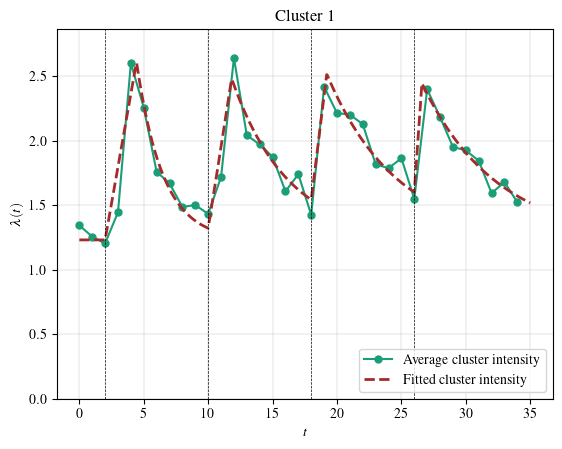

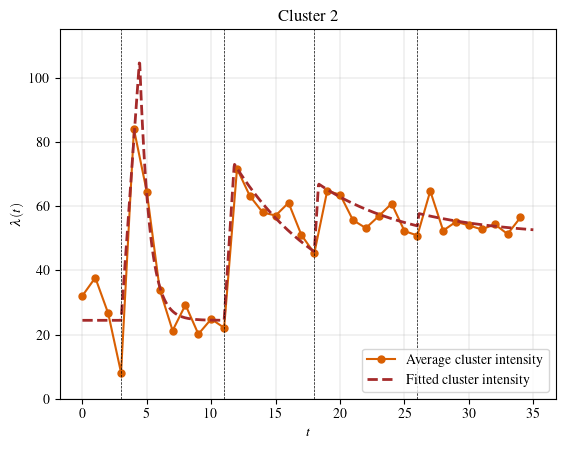

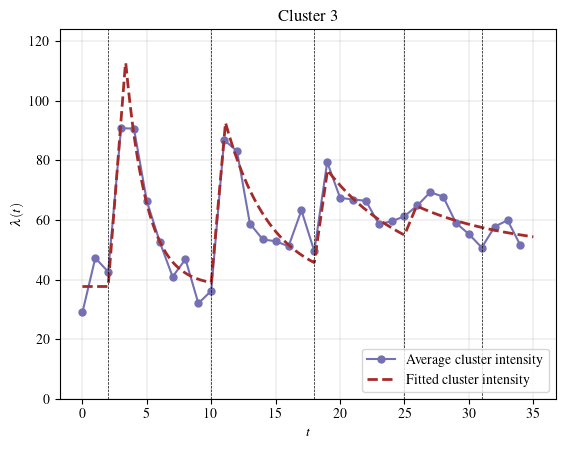

In [21]:
from scipy.optimize import minimize
## Repeat for all clusters
optimized_params_full = {}
## Colour palette
colors = plt.get_cmap('Dark2').colors
for k in range(K):
    ## Pre-specify the jump locations
    if k == 0: 
        jumps = np.array([ 2, 10, 18, 26]) # Adjust for zero-based indexing
    elif k == 1:
        jumps = np.array([ 2, 10, 18, 26])
        jumps[0] = 3; jumps[1] = 11
    elif k == 2:
        jumps = np.array([ 2, 10, 18, 26, 31])
        jumps[2] = 18; jumps[3] = 25
    # Initial parameter guess (see paper for details)
    Xlm = X[kmeans.labels_ == k].mean(axis=0)
    jumps_alpha = np.array([3, 11, 18, 26]) + 1 
    if k == 2:
        jumps_alpha[:2] = jumps_alpha[:2] - 1
        jumps_alpha = np.append(jumps_alpha, 31)
    lambda0 = np.mean(Xlm[:jumps_alpha[0]])
    alphas0 = np.diff(Xlm)[jumps_alpha - 1]
    theta0_alpha0 = alphas0[0]
    eta_alpha0 = np.abs(alphas0[1] - alphas0[0])
    csi_alpha0 = 0.1  # Initial guess for csi
    params = np.log([theta0_alpha0, eta_alpha0, csi_alpha0])
    res_alpha = minimize(hhf.inhibitory_loss, params, args=(alphas0, jumps_alpha), method='L-BFGS-B')
    params_init = np.log([lambda0] + list(np.exp(res_alpha.x)) + [1.5, 0.5, 0.1])
    # Minimize the negative log-likelihood
    result_init = minimize(hhf.negative_log_likelihood, params_init, args=(Xlm, jumps_alpha), method='L-BFGS-B')
    ## Optimize the parameters
    params = np.log(list(np.exp(result_init.x)) + [1.5, 0.5, 0.25])
    result = minimize(hhf.negative_log_likelihood_full, params, args=(Xlm, jumps), method='L-BFGS-B')
    ## Check if the optimization was successful
    # Extract the optimized parameters
    optimized_params = np.exp(result.x)
    optimized_params_full[k] = optimized_params
    ## Obtain the optimized parameters
    lambda0, theta0_alpha, eta_alpha, csi_alpha, theta0_beta, eta_beta, csi_beta, theta0_delta, eta_delta, csi_delta = optimized_params
    ## Obtain the values of alpha and beta at the jump locations
    alphas = hhf.inhibitory_hawkes_intensity(jumps, jumps, theta0_alpha, eta_alpha, csi_alpha)
    betas = hhf.inhibitory_hawkes_intensity(jumps, jumps, theta0_beta, eta_beta, csi_beta)
    deltas = hhf.inhibitory_hawkes_intensity(jumps, jumps, theta0_delta, eta_delta, csi_delta)
    ## Grid
    time_grid = np.linspace(0, X.shape[1], 1000)
    ints = np.ones_like(time_grid) * lambda0
    # Calculate the intensity function
    for j, jump in enumerate(jumps):
        c1 = alphas[j] / deltas[j] * np.clip(time_grid - jump, 0, deltas[j]) * (1 - np.heaviside(time_grid - jump - deltas[j], 1))
        c2 = np.heaviside(time_grid - jump - deltas[j], 1) * alphas[j] * np.exp(-betas[j] * (time_grid - jump - deltas[j]))  
        ints += (c1 + c2) * np.heaviside(time_grid - jump, 1) ## Plot the optimized intensity function
    plt.plot(Xlm, color=colors[k], linewidth=1.5, marker='o', markersize=5,
             label='Average cluster intensity')
    plt.plot(time_grid, ints, color='brown', linewidth=2, ls='dashed', label='Fitted cluster intensity')
    plt.ylim(0, np.max(ints) + np.max(ints) / 10)
    plt.xlabel(r'$t$')
    plt.ylabel(r'$\lambda(t)$')
    for jump in jumps:
        plt.axvline(x=jump, color='black', linestyle='--', linewidth=0.5)
    plt.legend(loc='lower right')
    plt.grid(linewidth=0.25)
    plt.title(f'Cluster {k+1}')
    plt.savefig(f'../figures/hierarchical_hawkes_intensity_full_{k}.pdf', bbox_inches='tight')
    plt.show()

Fit on the mean value of the process: 

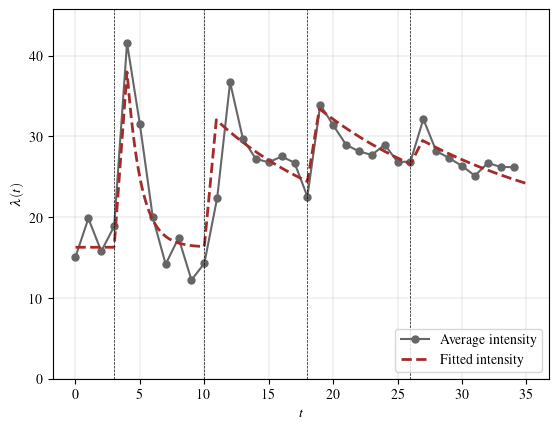

In [29]:
jumps = np.array([3, 10, 18, 26]) # Adjust for zero-based indexing
# Initial parameter guess (see paper for details)
Xlm = X.mean(axis=0)
jumps_alpha = np.array([3, 11, 18, 26]) + 1
lambda0 = np.mean(Xlm[:jumps_alpha[0]])
alphas0 = np.diff(Xlm)[jumps_alpha - 1]
theta0_alpha0 = alphas0[0]
eta_alpha0 = np.abs(alphas0[1] - alphas0[0])
csi_alpha0 = 0.1  # Initial guess for csi
params = np.log([theta0_alpha0, eta_alpha0, csi_alpha0])
res_alpha = minimize(hhf.inhibitory_loss, params, args=(alphas0, jumps_alpha), method='L-BFGS-B')
params_init = np.log([lambda0] + list(np.exp(res_alpha.x)) + [1.5, 0.5, 0.1])
# Minimize the negative log-likelihood
result_init = minimize(hhf.negative_log_likelihood, params_init, args=(Xlm, jumps_alpha), method='L-BFGS-B')
## Optimize the parameters
params = np.log(list(np.exp(result_init.x)) + [1.5, 0.5, 0.25])
result = minimize(hhf.negative_log_likelihood_full, params, args=(Xlm, jumps), method='L-BFGS-B')
# Extract the optimized parameters`
optimized_params = np.exp(result.x)
optimized_params_full[k] = optimized_params
## Obtain the optimized parameters
lambda0, theta0_alpha, eta_alpha, csi_alpha, theta0_beta, eta_beta, csi_beta, theta0_delta, eta_delta, csi_delta = optimized_params
## Obtain the values of alpha and beta at the jump locations
alphas = hhf.inhibitory_hawkes_intensity(jumps, jumps, theta0_alpha, eta_alpha, csi_alpha)
betas = hhf.inhibitory_hawkes_intensity(jumps, jumps, theta0_beta, eta_beta, csi_beta)
deltas = hhf.inhibitory_hawkes_intensity(jumps, jumps, theta0_delta, eta_delta, csi_delta)
## Grid
time_grid = np.linspace(0, X.shape[1], 1000)
ints = np.ones_like(time_grid) * lambda0
# Calculate the intensity function
for j, jump in enumerate(jumps):
    c1 = alphas[j] / deltas[j] * np.clip(time_grid - jump, 0, deltas[j]) * (1 - np.heaviside(time_grid - jump - deltas[j], 1))
    c2 = np.heaviside(time_grid - jump - deltas[j], 1) * alphas[j] * np.exp(-betas[j] * (time_grid - jump - deltas[j]))  
    ints += (c1 + c2) * np.heaviside(time_grid - jump, 1) ## Plot the optimized intensity function
## Plot the optimized intensity function
plt.plot(Xlm, color=colors[2*K+1], linewidth=1.5, marker='o', markersize=5,
            label='Average intensity')
plt.plot(time_grid, ints, color='brown', linewidth=2, ls='dashed', label='Fitted intensity')
plt.ylim(0, max([np.max(ints) + np.max(ints) / 10, np.max(Xlm) + np.max(Xlm) / 10]))
plt.xlabel(r'$t$')
plt.ylabel(r'$\lambda(t)$')
for jump in jumps:
    plt.axvline(x=jump, color='black', linestyle='--', linewidth=0.5)
plt.legend(loc='lower right')
plt.grid(linewidth=0.25)
plt.savefig(f'../figures/hierarchical_hawkes_intensity_full_mean.pdf', bbox_inches='tight')
plt.show()